# Outline

This notebook perform basic EDA. To help me decide how to prerpocess data and feature engineering.

Include these steps:

* Load data
* Data basic investigation
* Data visualization
* correlation map
* conclusion

In [1]:
# import necessary library
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder,LabelEncoder

# Load data

In [2]:
# config
class CFG:
    train_csv = '/kaggle/input/playground-series-s6e1/train.csv'
    test_csv = '/kaggle/input/playground-series-s6e1/test.csv'
    sample_submission_csv = '/kaggle/input/playground-series-s6e1/sample_submission.csv'
    N_FOLDS = 5
    RANDOM_SEED = 42
    
#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
train = pd.read_csv(CFG.train_csv)
test = pd.read_csv(CFG.test_csv)

# Data basic investigation

In [4]:
print("------------train data------------")
print(train.head())
print(train.describe())
print("------------test data------------")
print(test.head())
print(test.describe())

------------train data------------
   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc         7.91              98.8              no   
1   1   18   other  diploma         4.95              94.8             yes   
2   2   20  female     b.sc         4.68              92.6             yes   
3   3   19    male     b.sc         2.00              49.5             yes   
4   4   23    male      bca         7.65              86.9             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0          4.9       average  online videos             low            easy   
1          4.7          poor     self-study          medium        moderate   
2          5.8          poor       coaching            high        moderate   
3          8.3       average    group study            high        moderate   
4          9.6          good     self-study            high            easy   

   exam_score  
0    

In [5]:
train.isnull().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

Basic statistical results indicate that there is no difference between the training set and the test set.

And no missing data in train data set.

# Data visualization

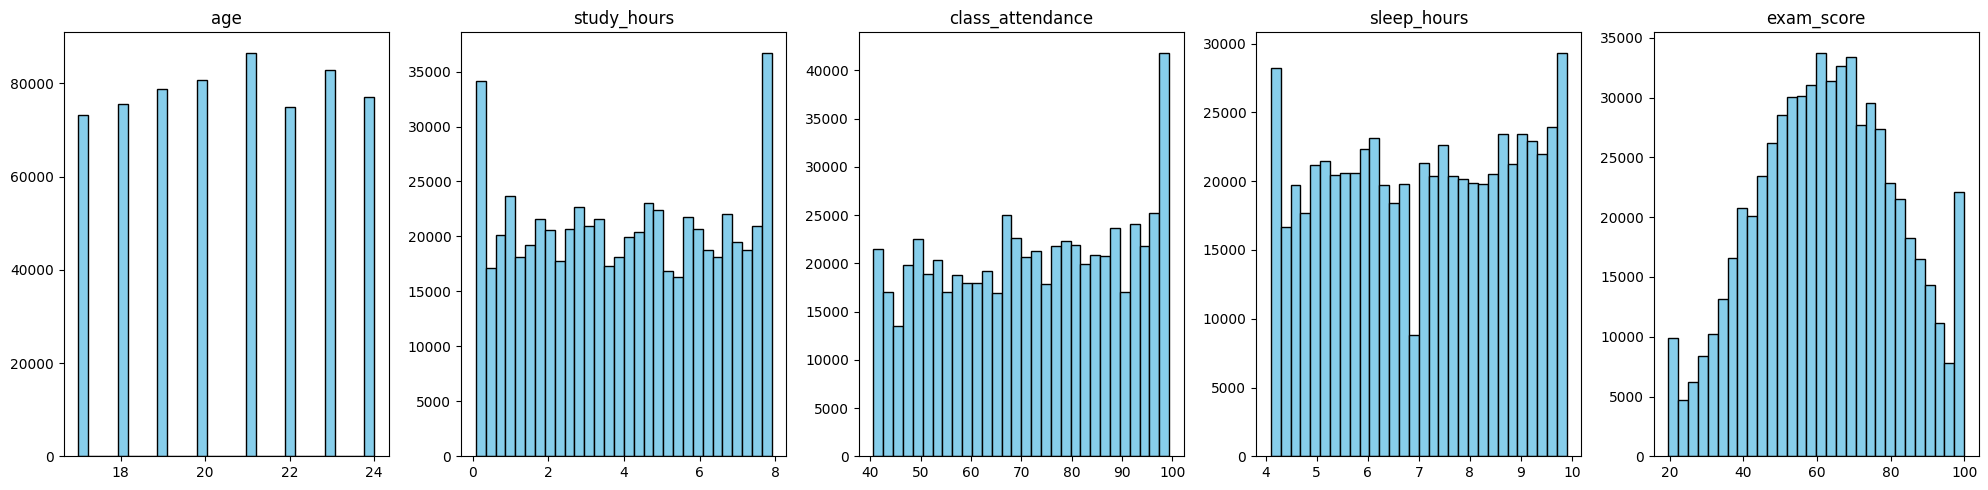

In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id']]
total_col = len(numeric_cols)
subplot_x = int(total_col / 5)
subplot_y = 5

fig, axs = plt.subplots(subplot_x, subplot_y, figsize=(20, 5)) # Adjust grid size as needed
axs = axs.flatten() # Flattens the 2D grid to 1D

for i, col in enumerate(numeric_cols):
    if i < len(axs):
        axs[i].hist(train[col], bins=30, color='skyblue', edgecolor='black')
        axs[i].set_title(col)
    else:
        axs[i].axis('off') # Hide unused subplots

plt.tight_layout()
plt.show()

From attribution above I can tell that most numerical data seems normal.

Some students have very high scores, some have very low scores, but most scores show a normal distribution.

As for age, class_attendence, study_hours and sleep_hours all seems to have a fair distribution.

But there are three thing need to be award. After prediction I might come back for further investigation.

1. Feature study_hours has a weird amount of number in almost didn't study(hours almost 0) and study almost 8 hours.
2. Feature class_attendence has a lot of people with 100% attendance. This might cause model be have a better prediction or overfitting at the student with 100% attendance.
3. Feature sleep_hours has a lot of students with 4 and 10 hours sleep. But there is hugh drop of number about 7 hours sleep. I suspect this may be some misleading data.

# Encode the data and visualize

In [7]:
non_numeric_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()
for col in non_numeric_cols:
    print(col," : ",train[col].unique())

gender  :  ['female' 'other' 'male']
course  :  ['b.sc' 'diploma' 'bca' 'b.com' 'ba' 'bba' 'b.tech']
internet_access  :  ['no' 'yes']
sleep_quality  :  ['average' 'poor' 'good']
study_method  :  ['online videos' 'self-study' 'coaching' 'group study' 'mixed']
facility_rating  :  ['low' 'medium' 'high']
exam_difficulty  :  ['easy' 'moderate' 'hard']


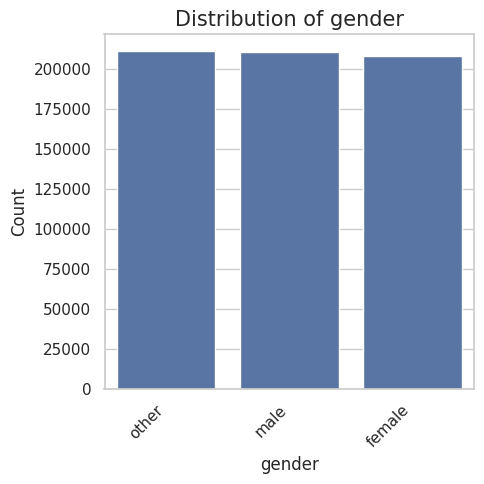

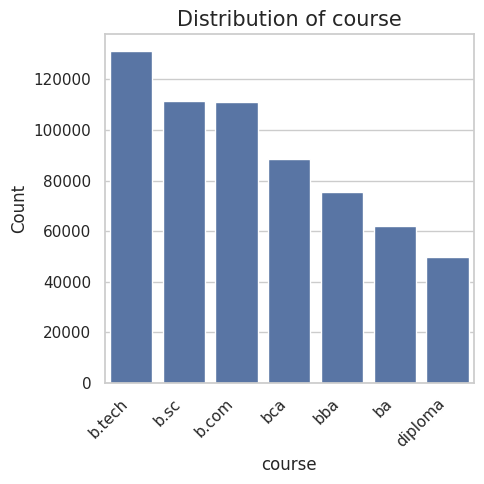

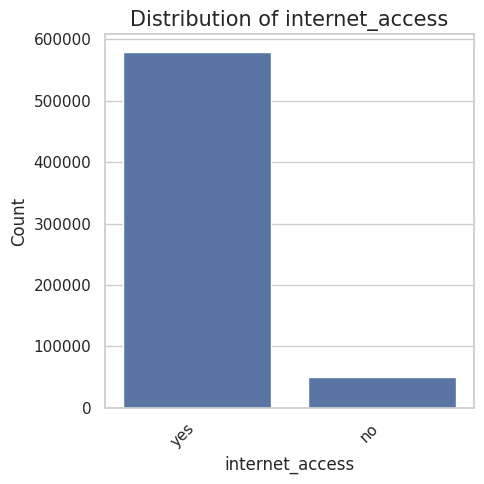

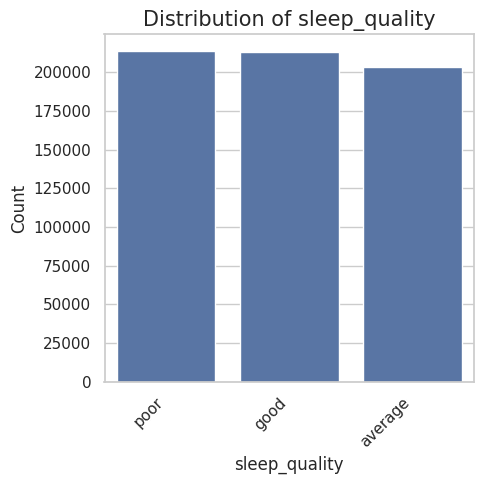

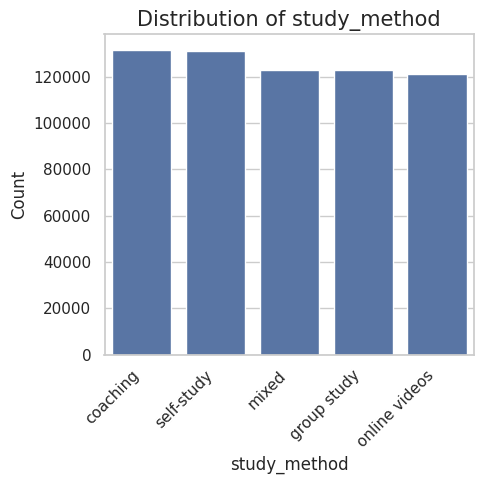

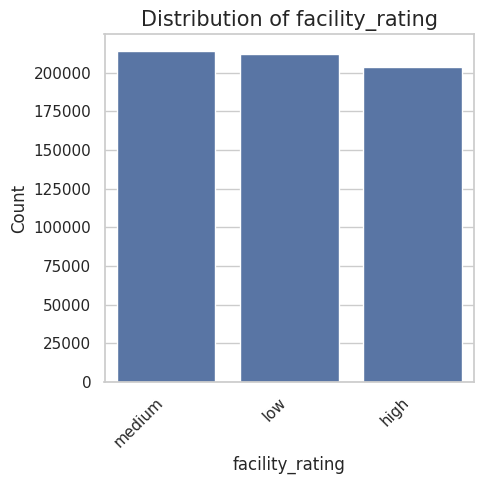

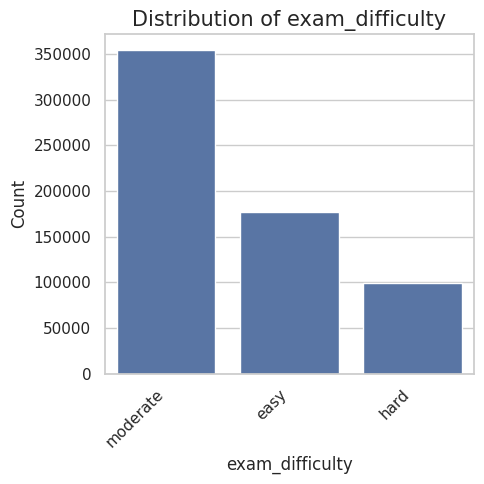

In [8]:
sns.set(style="whitegrid")
#PLOT NON NUMERIC DATA
for col in non_numeric_cols:
    # (width, height)
    plt.figure(figsize=(5, 5))
    
    # order plot with most number to least number data
    sns.countplot(data=train, x=col, order=train[col].value_counts().index)
    
    # title and x label
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # rotate to avoid x axis on top of each other
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

Most non numerical data above have a fair distribution.

I think there are inly two thing might need to focus.

1. Feature internet_access have a huge difference.
2. Feature exam_difficulty mostly is moderate. This is reasonable but this means when I encode this feature it need to have a level(1:easy, 2:moderate, 3:hard). **(sleep_quality, facility_rating, exam_difficulty need to encode with level)**

# Preprocess data

This function is set up after conculsion so some encoding and feature engineering will be explain in conclusion.

In [9]:
class Preprocessor:
    def __init__(self):
        self.medians = {}
        self.encoders = {}
        self.numeric_cols = []
        self.all_non_numeric = []
        self.categorical_cols = []
        self.level_mapping = {'easy': 1, 'moderate': 2, 'hard': 3,
                              'low': 1, 'medium': 2, 'high': 3,
                              'poor': 1, 'average': 2, 'good': 3}
        self.level_cols = ['sleep_quality', 'facility_rating', 'exam_difficulty']
        
    def fit(self, df):
        """
        Learn the parameters (medians, categories) from the TRAINING data.
        """
        # Identify columns
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        self.all_non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
        self.categorical_cols = [c for c in self.all_non_numeric if c not in self.level_cols]
        
        # Learn Medians for numeric columns
        for col in self.numeric_cols:
            self.medians[col] = df[col].median()
            
        # Fit Encoders for categorical columns
        # handle_unknown='use_encoded_value' prevents crashes if Test data has new categories
        for col in self.categorical_cols:
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            enc.fit(df[[col]].astype(str)) 
            self.encoders[col] = enc
            
        return self

    def transform(self, df):
        """
        Apply the learned parameters to the data (Train or Test).
        """
        df = df.copy()
        
        # Drop irrelevant columns (ID is usually dropped, Target handled separately)
        # Note: We don't drop target here to keep X and y aligned until the end
        if 'id' in df.columns:
            df = df.drop(columns=['id'])

        # level encoding
        for col in self.level_cols:
            if col in df.columns:
                # ues mapping rule fillna with 0 
                df[col] = df[col].map(self.level_mapping).fillna(0).astype(int)
        # Impute Missing Values using LEARNED medians
        for col in self.numeric_cols:
            if col in df.columns:
                df[col] = df[col].fillna(self.medians.get(col, 0))
        
        # Apply Encoding
        for col in self.categorical_cols:
            if col in df.columns:
                # Fill NaN in categoricals with 'Missing' before encoding to be safe
                df[col] = df[col].astype(str).fillna('Missing')
                df[col] = self.encoders[col].transform(df[[col]]).flatten()
        
        return df
        
    def create_interaction_features(self, df):# add because of the Correlation matrix
        df = df.copy()
        
        # sleep_hours * sleep_quality
        # assumption : sleep_quality might increase value of sleep_hours
        if 'sleep_hours' in df.columns and 'sleep_quality' in df.columns:
            df['sleep_hours_quality'] = df['sleep_hours'] * df['sleep_quality']
            
        # class_attendance * facility_rating
        # assumption : better facility_rating with increase the effect class_attendance
        if 'class_attendance' in df.columns and 'facility_rating' in df.columns:
            df['facility_rating_attendance'] = df['class_attendance'] * df['facility_rating']
            
        # study_method * study_hours
        # study_method might increase value of study_hours
        if 'study_method' in df.columns and 'study_hours' in df.columns:
            df['study_method_hours'] = df['study_method'] * df['study_hours']
        
        return df

In [10]:
preprocessor = Preprocessor()

X_train_raw = train#.drop(columns=['exam_score'])
y_train = train['exam_score']

# learn the rule (median value...)
preprocessor.fit(X_train_raw)

# preprocess data
X_train_processed = preprocessor.transform(X_train_raw)

In [11]:
X_train_processed.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,0.0,1.0,7.91,98.8,0.0,4.9,2,3.0,1,1,78.3
1,18,2.0,6.0,4.95,94.8,1.0,4.7,1,4.0,2,2,46.7
2,20,0.0,1.0,4.68,92.6,1.0,5.8,1,0.0,3,2,99.0
3,19,1.0,1.0,2.00,49.5,1.0,8.3,2,1.0,3,2,63.9
4,23,1.0,5.0,7.65,86.9,1.0,9.6,3,4.0,3,1,100.0


In [12]:
X_train_interact_feature = preprocessor.create_interaction_features(X_train_processed)
X_train_interact_feature.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,sleep_hours_quality,facility_rating_attendance,study_method_hours
0,21,0.0,1.0,7.91,98.8,0.0,4.9,2,3.0,1,1,78.3,9.8,98.8,23.73
1,18,2.0,6.0,4.95,94.8,1.0,4.7,1,4.0,2,2,46.7,4.7,189.6,19.80
2,20,0.0,1.0,4.68,92.6,1.0,5.8,1,0.0,3,2,99.0,5.8,277.8,0.00
3,19,1.0,1.0,2.00,49.5,1.0,8.3,2,1.0,3,2,63.9,16.6,148.5,2.00
4,23,1.0,5.0,7.65,86.9,1.0,9.6,3,4.0,3,1,100.0,28.8,260.7,30.60


# correlation map

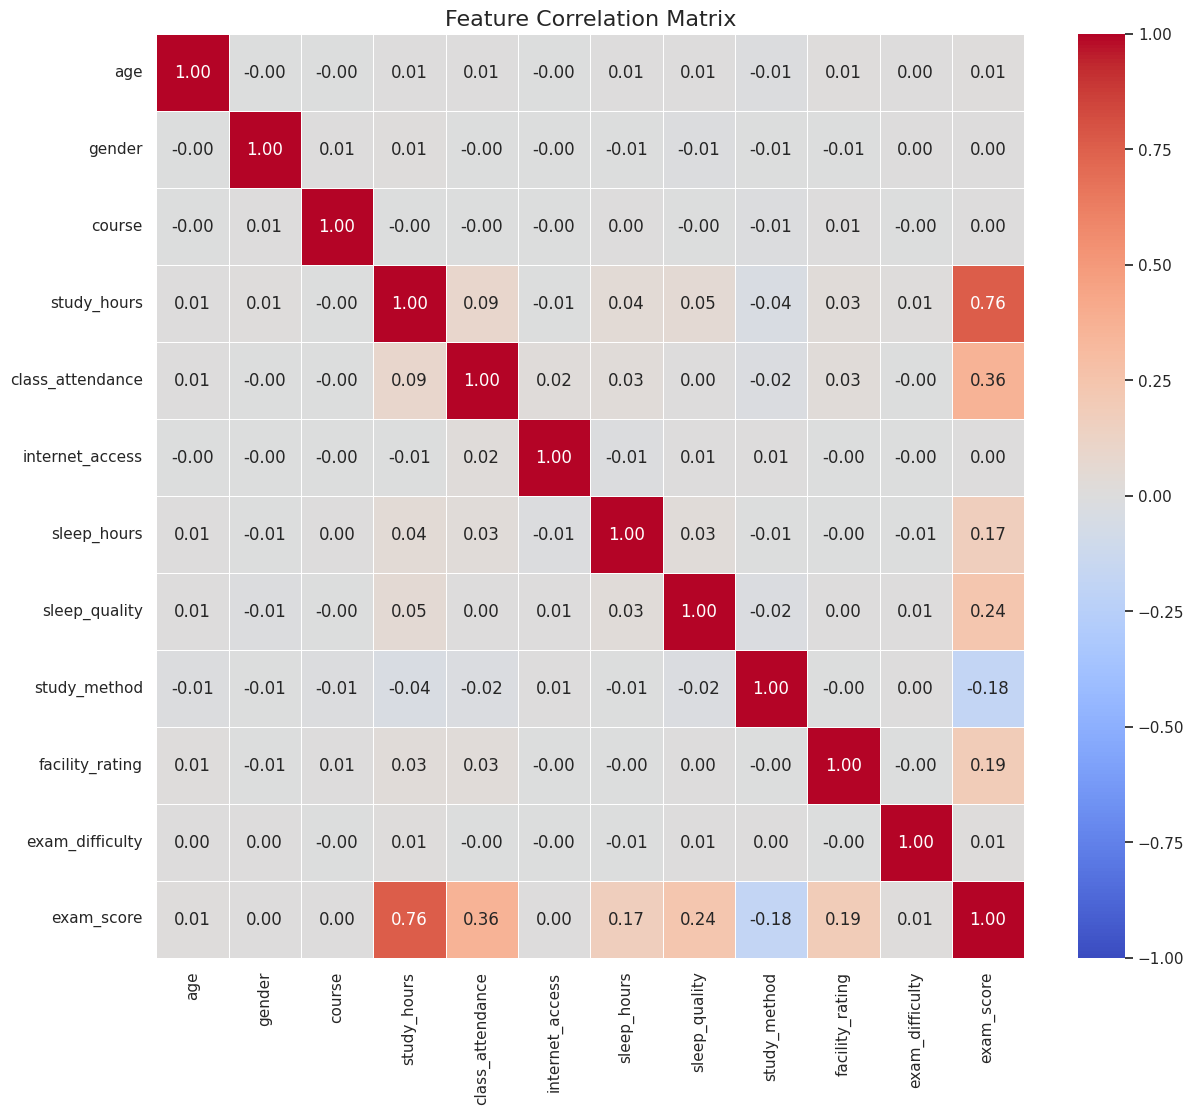

In [13]:
# We use the processed data so categorical columns (encoded as numbers) are included
corr_matrix = X_train_processed.corr()

# Setup the figure size (make it large enough to read)
plt.figure(figsize=(14, 12))

# Create the Heatmap
# annot=True: shows the numbers
# cmap='coolwarm': Blue for negative corr, Red for positive
# fmt=".2f": limits decimals to 2 places
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

# Conclusion



Numeric data:

1. Study_hours has a weird amount of number in almost didn't study(hours almost 0) and study almost 8 hours.
2. Class_attendence has a lot of people with 100% attendance. This is a reaonable data but might cause model overfitting.
3. Sleep_hours has a lot of students with 4 and 10 hours sleep. But there is hugh drop of number about 7 hours sleep. I suspect this may be some misleading data.

Non numeric data:

1. Sleep_quality, facility_rating and exam_difficulty need to encode with level.
2. Internet_access have a huge difference in number. This might cause overfitting.

Heatmap:

1. Exam_score have strong correlation with study_hours(0.76). This shows that exam_score have high possibility to be main feature in predicting data.
2. Class_attendance, sleep_hours, sleep_quality,facility_rating these four features all have some realation toward exam_score. So I wil do some feature interaction betweeneach other. Ex: sleep_hours * sleep_quality, class_attendance * facility_rating
3. There is an interesting correlation between study_method and exam_score. I will interact it with study_hour first. Later this might need some further investgation.
4. Each feature don't have any relation between each other.
5. One interesting thing I find is that exam_difficulity don't have any realation with exam_score. I believe that the easier the exam, the higher the score. So this is a little bit weird.